## Практика 6. Построение MLP-модели на Keras и сравнение качества с классическими ML-моделями

In [143]:
import keras
import pandas as pd

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam

from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [144]:
titanic_data_train = pd.read_csv('titanic_train_median_processed.csv')
titanic_data_valid = pd.read_csv('titanic_valid_median_processed.csv')

titanic_data_train.head()

,num__SibSp,num__Parch,num__Fare,cat__Sex_female,cat__Sex_male,cat__Embarked_C,cat__Embarked_Q,cat__Embarked_S,cat__Title_Master,cat__Title_Miss,cat__Title_Mr,cat__Title_Mrs,cat__Title_Rare,age__Age,pclass__Pclass,Survived
0,0.0,0.0,1.819652,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.000000,3.0,1
1,0.0,0.0,-0.625609,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.000000,2.0,0
2,0.0,0.0,8.973477,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.000000,1.0,0
3,0.0,1.0,-0.220921,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,-0.750000,3.0,1
4,1.0,1.0,0.510548,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.178571,2.0,1


In [145]:
X_train_mlp = titanic_data_train.drop("Survived", axis=1)
y_train_mlp = titanic_data_train["Survived"]

X_valid_mlp = titanic_data_valid.drop("Survived", axis=1)
y_valid_mlp = titanic_data_valid["Survived"]

In [146]:
mlp_model = Sequential([
    Dense(32, activation="relu"),
    Dropout(0.2),

    Dense(16, activation="relu"),
    Dropout(0.2),

    Dense(1, activation="sigmoid")
])

mlp_model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

history = mlp_model.fit(
    X_train_mlp,
    y_train_mlp,
    validation_data=(X_valid_mlp, y_valid_mlp),
    epochs=50,
    batch_size=32
)

y_proba = mlp_model.predict(X_valid_mlp)
y_pred = (y_proba >= 0.5).astype(int).ravel()


Epoch 1/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.3876 - loss: 0.9495 - val_accuracy: 0.3966 - val_loss: 0.7863
Epoch 2/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.4958 - loss: 0.7242 - val_accuracy: 0.6201 - val_loss: 0.6671
Epoch 3/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6545 - loss: 0.6481 - val_accuracy: 0.6592 - val_loss: 0.6150
Epoch 4/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.6868 - loss: 0.5977 - val_accuracy: 0.6704 - val_loss: 0.5817
Epoch 5/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7093 - loss: 0.5844 - val_accuracy: 0.6872 - val_loss: 0.5549
Epoch 6/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.7472 - loss: 0.5527 - val_accuracy: 0.7318 - val_loss: 0.5326
Epoch 7/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7584 - loss: 0.5311 - val_accuracy: 0.7709 - val_loss: 0.5148
Epoch 8/50
23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.7795 - loss: 0.5083 - val_accuracy: 0.7765 - val_loss:

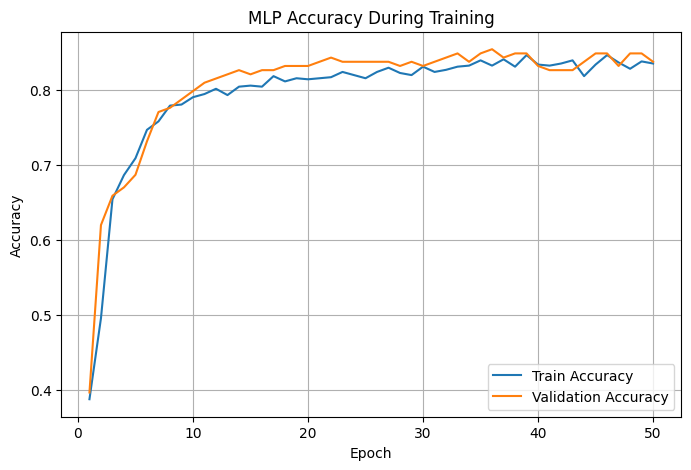

In [147]:
history_df = pd.DataFrame(history.history)
history_df["epoch"] = range(1, len(history_df) + 1)

history_df.head()

plt.figure(figsize=(8, 5))

sns.lineplot(data=history_df, x="epoch", y="accuracy", label="Train Accuracy")
sns.lineplot(data=history_df, x="epoch", y="val_accuracy", label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("MLP Accuracy During Training")
plt.grid(True)
plt.show()

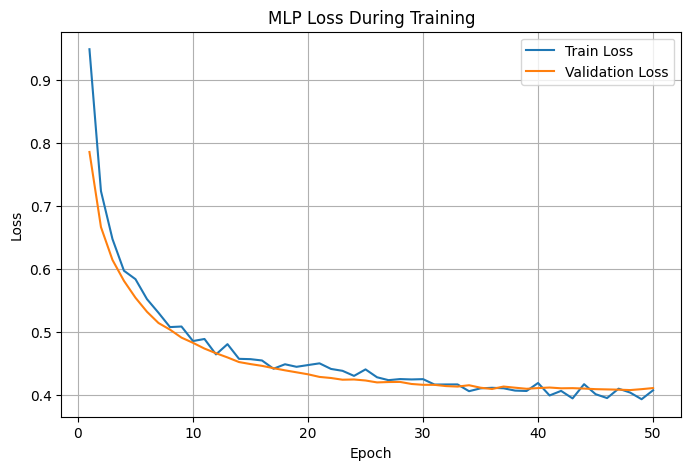

In [148]:
plt.figure(figsize=(8, 5))

sns.lineplot(data=history_df, x="epoch", y="loss", label="Train Loss")
sns.lineplot(data=history_df, x="epoch", y="val_loss", label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("MLP Loss During Training")
plt.grid(True)
plt.show()

In [149]:
print("Validation Accuracy:", accuracy_score(y_valid_mlp, y_pred))
print("Validation F1:", f1_score(y_valid_mlp, y_pred))

print(classification_report(y_valid_mlp, y_pred))
print(confusion_matrix(y_valid_mlp, y_pred))

Validation Accuracy: 0.8379888268156425
Validation F1: 0.7603305785123967
              precision    recall  f1-score   support

           0       0.82      0.95      0.88       110
           1       0.88      0.67      0.76        69

    accuracy                           0.84       179
   macro avg       0.85      0.81      0.82       179
weighted avg       0.84      0.84      0.83       179

[[104   6]
 [ 23  46]]


| model_name                           | best_cv_f1 | best_cv_accuracy | valid_accuracy | valid_f1 |
| ------------------------------------ | ---------: | ---------------: | -------------: | -------: |
| Logistic Regression by median impute |   0.761438 |         0.823057 |       0.849162 | 0.793893 |
| Decision Tree by median impute       |   0.756929 |         0.824505 |       0.832402 | 0.776119 |
| Random Forest by median impute       |   0.768910 |         0.831478 |       0.821229 | 0.757576 |


### Сравнение качества с классическими ML моделями. 

В данном анализе сравниваются результаты MLP с результатами логистической регрессии, дерева решений и случайного леса с подставлением возраста медианным значением, так как в предыдущем анализе было выяснено, что поставление по полу и пассажирскому классу не улучшает качество работы вышеперечисленных алгоритмов. 

Без подбора гиперпараметров, MLP с двумя скрытыми слоями, по 32 и 16 нейронов соответственно, показывает данное качество на валидационной выборке: `Accuracy - 0.84`, `F1 - 0.76`. Через сравнение метрик, можно увидеть, что MLP в данном случае работает хуже, чем логистическая регрессия (`Accuracy - 0.85`, `F1 - 0.79`), но лучше, чем или одинаково с деревом решений и случайным лесом. 

По отчету классификации видно, что MLP лучше справляется с классом `0` — пассажиры, которые не выжили: recall для этого класса равен `0.95`. Однако модель хуже находит выживших пассажиров: для класса `1` recall составляет `0.67`. Это дальше подтверждается матрицей ошибок - модель ошибочно отнесла 23 пассажира к невыжившим. 